# Bank Customer Churn Prediction 

## This project aims to build a classification model to predict whether a bank customer will churn. Identify the most influential features contributing to churn and develop a high-performance model to detect at-risk customers in advance.

______________________________________________________________________________________________________________________________________

## Problem Statement

### Objective

To forecast future churn (Exited) for each customer (ID) based on their informations.
This will contribute to:

・Making Strategy and approaches for future customer who will churn



### Problem Type
Classification problem

### Objective Variable (Target)
Exited:customer who churned bank

### Evaluation Metric

RMSLE (Root Mean Squared Logarithmic Error):
Calculated using the root mean square of the logarithmic difference between forecast and actual sales.


In [16]:
# pip install prettytable

In [17]:
# pip install category_encoders

________________________________________________________________________________________________
# 1. Import libraries and dataset

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prettytable import PrettyTable

from category_encoders import OneHotEncoder, GLMMEncoder, TargetEncoder, CatBoostEncoder
from sklearn import set_config
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import roc_auc_score, roc_curve, make_scorer, f1_score
from sklearn.preprocessing import FunctionTransformer, StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import VotingClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

sns.set_theme(style = 'white', palette = 'viridis')
pal = sns.color_palette('viridis')

pd.set_option('display.max_rows', 100)
set_config(transform_output = 'pandas')
pd.options.mode.chained_assignment = None

import warnings
warnings.filterwarnings('ignore')

In [19]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [20]:
import zipfile

with zipfile.ZipFile('playground-series-s4e1.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

In [21]:
df_submission = pd.read_csv('data/sample_submission.csv')
df_test = pd.read_csv('data/test.csv')
df_train = pd.read_csv('data/train.csv')

__________________________________________________________________________________________________
## 2. EDA

### 2-1. Detail information of each dataframes

In [22]:
print(f'Sample submission file: {df_submission.shape}\n')

print(f'Infomation :\n{df_submission.info()}')
df_submission.head()

Sample submission file: (110023, 2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110023 entries, 0 to 110022
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      110023 non-null  int64  
 1   Exited  110023 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 1.7 MB
Infomation :
None


,id,Exited
0,165034,0.5
1,165035,0.5
2,165036,0.5
3,165037,0.5
4,165038,0.5


In [23]:
print(f'Test file:\n{df_test.shape}\n')


print(f'Infomation :\n{df_test.info()}')
df_test.head()

Test file:
(110023, 13)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110023 entries, 0 to 110022
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               110023 non-null  int64  
 1   CustomerId       110023 non-null  int64  
 2   Surname          110023 non-null  object 
 3   CreditScore      110023 non-null  int64  
 4   Geography        110023 non-null  object 
 5   Gender           110023 non-null  object 
 6   Age              110023 non-null  float64
 7   Tenure           110023 non-null  int64  
 8   Balance          110023 non-null  float64
 9   NumOfProducts    110023 non-null  int64  
 10  HasCrCard        110023 non-null  float64
 11  IsActiveMember   110023 non-null  float64
 12  EstimatedSalary  110023 non-null  float64
dtypes: float64(5), int64(5), object(3)
memory usage: 10.9+ MB
Infomation :
None


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,165034,15773898,Lucchese,586,France,Female,23.0,2,0.00,2,0.0,1.0,160976.75
1,165035,15782418,Nott,683,France,Female,46.0,2,0.00,1,1.0,0.0,72549.27
2,165036,15807120,K?,656,France,Female,34.0,7,0.00,2,1.0,0.0,138882.09
3,165037,15808905,O'Donnell,681,France,Male,36.0,8,0.00,1,1.0,0.0,113931.57
4,165038,15607314,Higgins,752,Germany,Male,38.0,10,121263.62,1,1.0,0.0,139431.00


In [24]:
print(f'Train file:\n{df_train.shape}')

print(f'Infomation :\n{df_train.info()}')
df_train.head()

Train file:
(165034, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  object 
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  object 
 5   Gender           165034 non-null  object 
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 17.6+ MB
Infomation :
None


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


### 2-2. Finding null values

In [25]:
files = [df_submission, df_train, df_test]
names = ['df_submission', 'df_train', 'df_test']

for name, df in zip(names, files):
    if df.isnull().sum().sum() == 0:
        print(f'{name} does not have null values.')
    else:
        print(f'{name} has null values:')
        print(df.isnull().sum())

df_submission does not have null values.
df_train does not have null values.
df_test does not have null values.


### 2-3. Finding duplicated values

In [26]:
files = [df_submission, df_train, df_test]
names = ['df_submission', 'df_train', 'df_test']

for name, df in zip(names, files):
    if df.duplicated().sum().sum() == 0:
        print(f'{name} does not have duplicated values.')
    else:
        print(f'{name} has duplicated values:')
        print(df.duplicated().sum())

df_submission does not have duplicated values.
df_train does not have duplicated values.
df_test does not have duplicated values.


### 2-4. Distribution

In [27]:
df_train.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.0000,1.650340e+05,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,82516.5000,1.569201e+07,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,47641.3565,7.139782e+04,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,0.0000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41258.2500,1.563314e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,82516.5000,1.569017e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,123774.7500,1.575682e+07,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,165033.0000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [28]:
df_test.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,110023.000000,1.100230e+05,110023.000000,110023.000000,110023.000000,110023.000000,110023.000000,110023.000000,110023.000000,110023.000000
mean,220045.000000,1.569210e+07,656.530789,38.122205,4.996637,55333.611354,1.553321,0.753043,0.495233,112315.147765
std,31761.048671,7.168499e+04,80.315415,8.861550,2.806148,62788.519675,0.544714,0.431244,0.499980,50277.048244
min,165034.000000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000
25%,192539.500000,1.563286e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74440.325000
50%,220045.000000,1.569018e+07,660.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117832.230000
75%,247550.500000,1.575693e+07,710.000000,42.000000,7.000000,120145.605000,2.000000,1.000000,1.000000,154631.350000
max,275056.000000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000


### 2-5. Visualization : Distribution of target feature

In [29]:
df_train.drop(columns=["id", "CustomerId"],inplace=True)
df_test.drop(columns=["id", "CustomerId"],inplace=True)
target = 'Exited'
sns.set_palette("Set2")

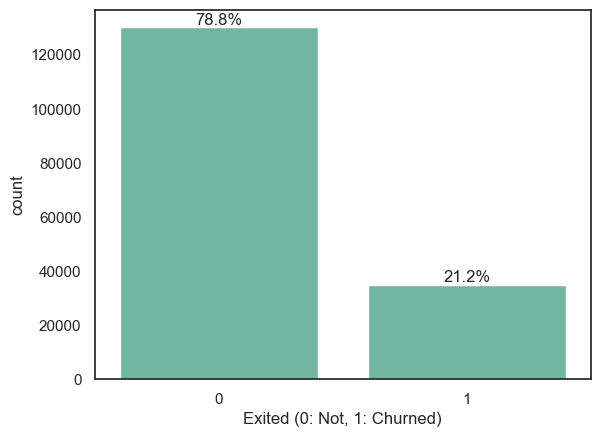

In [30]:
ax = sns.countplot(x=target, data=df_train)
ax.bar_label(ax.containers[0], labels=[f'{100 * p / len(df_train):.1f}%' for p in df_train[target].value_counts()])
plt.xlabel('Exited (0: Not, 1: Churned)')
plt.show()


### 2-6. Visualization : Distribution og all features

In [31]:
df_train.head()

,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

train_columns = df_train.copy()
if 'Surname' in train_columns.columns:
    train_columns = train_columns.drop(columns=['Surname'])






# ターゲット変数と特徴量の定義
target = 'Exited'
num_cols = train_columns.drop(target, axis=1).columns

# グラフレイアウト
n_rows, n_cols = 5, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 20))
axes = axes.flatten()

# グラフ生成
for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.histplot(data=train_columns, x=col, hue=target, multiple='stack', bins=30, ax=ax)

    # 平均・中央値の計算
    mean_val = train_columns[col].mean()
    median_val = train_columns[col].median()

    # 平均（赤）と中央値（青）の線を描画
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label='Mean')
    ax.axvline(median_val, color='blue', linestyle='-', linewidth=1.5, label='Median')

    ax.set_title(f'{col}', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.legend()

# 余分なサブプロットを削除
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


AttributeError: 'function' object has no attribute 'columns'

In [18]:
# Create a new binary feature 'ZeroBalance'
df_train['ZeroBalance'] = (df_train['Balance'] == 0).astype(int)
df_test['ZeroBalance'] = (df_test['Balance'] == 0).astype(int)

___________________________________________________________________________________________________________
## 3. Feature Engineering

### 3-1. TFIDF-PCA (Text Transformation) for Surname

In [19]:
# pip install wordcloud

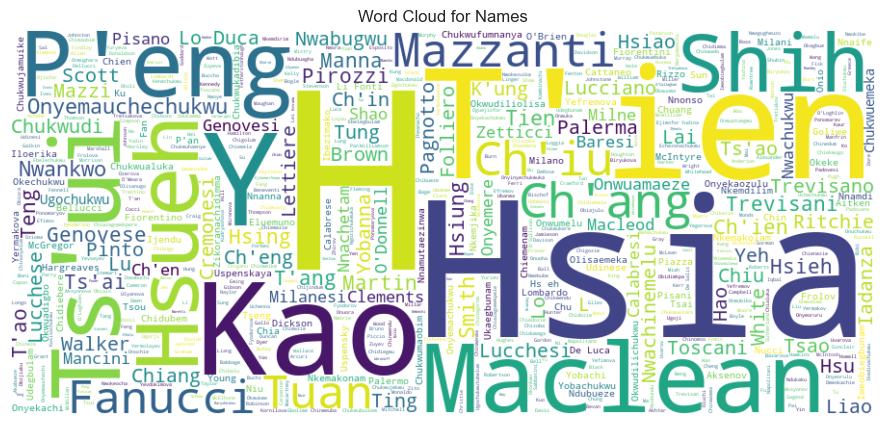

In [20]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=900, height=400, max_words=600, background_color='white').generate(' '.join(df_train['Surname']))

# Display the WordCloud
plt.figure(figsize=(20, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Names')
plt.show()


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

In [22]:
def tf_idf(df_train, df_test, column,n,p):
    vectorizer=TfidfVectorizer(max_features=n)
    vectors_train=vectorizer.fit_transform(df_train[column])
    vectors_test=vectorizer.transform(df_test[column])
    
    svd=TruncatedSVD(p)
    x_pca_train=svd.fit_transform(vectors_train)
    x_pca_test=svd.transform(vectors_test)
    tfidf_df_train=pd.DataFrame(x_pca_train)
    tfidf_df_test=pd.DataFrame(x_pca_test)

    
    cols=[(column+"_tfidf_"+str(f)) for f in tfidf_df_train.columns]
    tfidf_df_train.columns=cols
    tfidf_df_test.columns=cols
    df_train=pd.concat([df_train,tfidf_df_train], axis="columns")
    df_test=pd.concat([df_test,tfidf_df_test], axis="columns")
    
    return df_train, df_test

df_train,df_test=tf_idf(df_train,df_test,"Surname",1000,5)
df_train.drop(columns=["Surname"], inplace=True)
df_test.drop(columns=["Surname"], inplace=True)


In [23]:
df_train.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ZeroBalance,Surname_tfidf_truncatedsvd0,Surname_tfidf_truncatedsvd1,Surname_tfidf_truncatedsvd2,Surname_tfidf_truncatedsvd3,Surname_tfidf_truncatedsvd4
0,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0,1,-1.956404e-07,-7.889741e-07,-5.736296e-07,0.000002,-0.000004
1,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0,1,1.450136e-07,2.848462e-07,9.911642e-07,-0.000004,0.000012
2,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0,1,-9.227178e-04,-8.884308e-03,2.371248e-03,0.014157,0.004903
3,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0,0,6.950241e-04,4.727626e-03,6.123463e-04,0.005210,-0.005663
4,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0,1,-3.262454e-08,-4.350195e-08,3.330601e-07,-0.000003,-0.000006


In [24]:
df_test.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,ZeroBalance,Surname_tfidf_truncatedsvd0,Surname_tfidf_truncatedsvd1,Surname_tfidf_truncatedsvd2,Surname_tfidf_truncatedsvd3,Surname_tfidf_truncatedsvd4
0,586,France,Female,23.0,2,0.00,2,0.0,1.0,160976.75,1,-0.000012,-0.000002,-0.000010,-0.000111,-0.000021
1,683,France,Female,46.0,2,0.00,1,1.0,0.0,72549.27,1,0.000000,0.000000,0.000000,0.000000,0.000000
2,656,France,Female,34.0,7,0.00,2,1.0,0.0,138882.09,1,0.000000,0.000000,0.000000,0.000000,0.000000
3,681,France,Male,36.0,8,0.00,1,1.0,0.0,113931.57,1,-0.000001,0.000011,0.000018,0.000040,0.000009
4,752,Germany,Male,38.0,10,121263.62,1,1.0,0.0,139431.00,0,0.000000,0.000000,0.000000,0.000000,0.000000


## 3-2. External data

In [25]:
cet_bycountry = pd.read_csv('data/External_data_ECB/cet1_avg_2016.csv') 
cet_bycountry.head()

,Geography,avg_cet1_capital_2016
0,Spain,195.532700
1,Germany,192.661475
2,France,316.698050


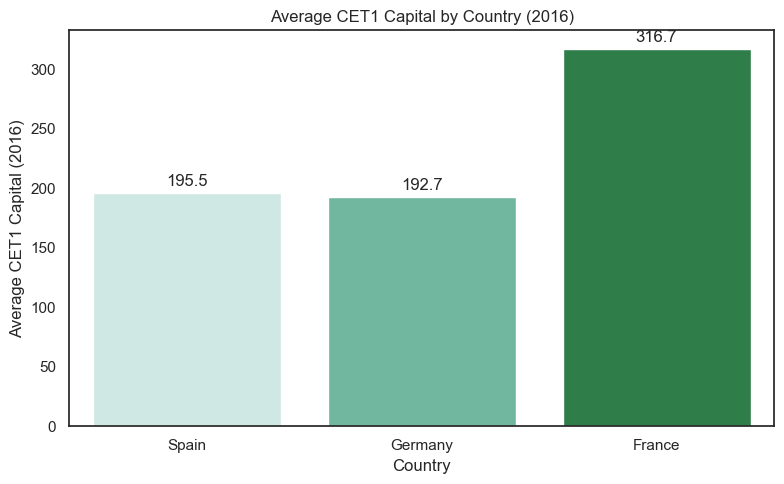

In [26]:
plt.figure(figsize=(8, 5))
bars = sns.barplot(
    data=cet_bycountry,
    x='Geography',
    y='avg_cet1_capital_2016',
    palette = "BuGn"
)


plt.xlabel('Country')
plt.ylabel('Average CET1 Capital (2016)')
plt.title('Average CET1 Capital by Country (2016)')


for container in bars.containers:
    bars.bar_label(container, fmt='%.1f', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

In [27]:
df_train = pd.merge(df_train, cet_bycountry, how='left', on='Geography')
df_test = pd.merge(df_test, cet_bycountry, how='left', on='Geography')
df_train.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,ZeroBalance,Surname_tfidf_truncatedsvd0,Surname_tfidf_truncatedsvd1,Surname_tfidf_truncatedsvd2,Surname_tfidf_truncatedsvd3,Surname_tfidf_truncatedsvd4,avg_cet1_capital_2016
0,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0,1,-1.956404e-07,-7.889741e-07,-5.736296e-07,0.000002,-0.000004,316.69805
1,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0,1,1.450136e-07,2.848462e-07,9.911642e-07,-0.000004,0.000012,316.69805
2,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0,1,-9.227178e-04,-8.884308e-03,2.371248e-03,0.014157,0.004903,316.69805
3,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0,0,6.950241e-04,4.727626e-03,6.123463e-04,0.005210,-0.005663,316.69805
4,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0,1,-3.262454e-08,-4.350195e-08,3.330601e-07,-0.000003,-0.000006,195.53270


### 3-2. Encoding categorical feature

In [28]:

categorical_features = ['Geography', 'Gender']


df_train = pd.get_dummies(df_train, columns=categorical_features, drop_first=True)
df_test = pd.get_dummies(df_test, columns=categorical_features, drop_first=True)

### 3-3. Handling outliers

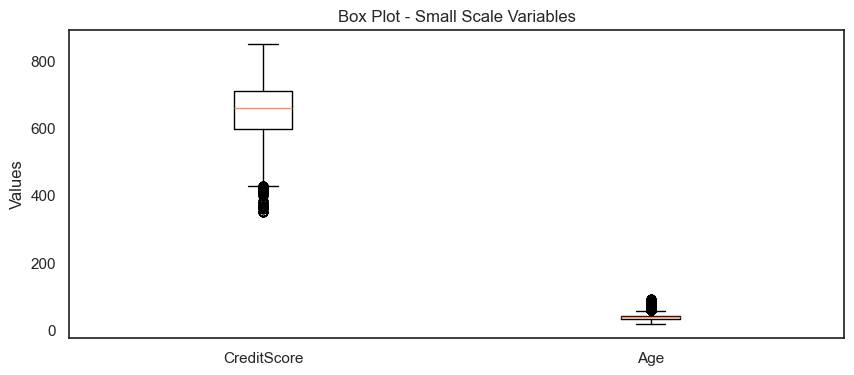

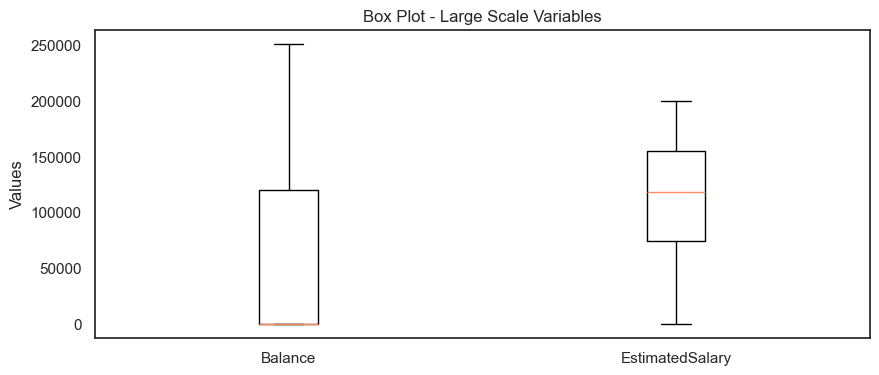

In [29]:
# 小さい値の変数（CreditScore, Age, Tenure）
small_scale_cols = ['CreditScore', 'Age']
# 大きい値の変数（Balance, EstimatedSalary）
large_scale_cols = ['Balance', 'EstimatedSalary']

# 小さいグループ
plt.figure(figsize=(10, 4))
plt.boxplot([df_train[col] for col in small_scale_cols], labels=small_scale_cols)
plt.title('Box Plot - Small Scale Variables')
plt.ylabel('Values')
plt.show()

# 大きいグループ
plt.figure(figsize=(10, 4))
plt.boxplot([df_train[col] for col in large_scale_cols], labels=large_scale_cols)
plt.title('Box Plot - Large Scale Variables')
plt.ylabel('Values')
plt.show()


In [30]:
# pip install sweetviz

In [31]:
# pip install --upgrade ipywidgets

## 3-4. Visualization by sweetviz

In [32]:
# import sweetviz as sv
# report = sv.compare([df_train, "Train Data"], [df_test, "Test Data"])


In [33]:
# report.show_notebook(w="100%", h="full")

_________________________________________________________________________________________________________
## 4. Modeling

In [34]:
# Select X and y
X = df_train.drop(columns=['Exited'])
y = df_train['Exited']

In [35]:
from sklearn.preprocessing import LabelEncoder

# Label encode target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


## 4-1. XGboost

In [36]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

# 必要に応じて X, y を定義済みと仮定
# X, y = ...

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 1200, 1400),
        'learning_rate': trial.suggest_float('learning_rate', 0.015, 0.022),
        'max_depth': trial.suggest_int('max_depth', 5, 7),
        'subsample': trial.suggest_float('subsample', 0.65, 0.75),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.42, 0.47),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 7),
        'tree_method': 'hist',
        'eval_metric': 'auc',
        'verbosity': 0,
        'random_state': 42
    }

    xgb_model = XGBClassifier(**params)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc = cross_val_score(xgb_model, X, y, scoring='roc_auc', cv=skf).mean()

    return auc

# Optuna Study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

print("Best trial:")
print(study.best_trial)
print("Best params:")
print(study.best_params)



[I 2025-05-29 15:13:38,487] A new study created in memory with name: no-name-d3fabe80-d2ad-4136-8175-55e176f32e56
[I 2025-05-29 15:16:14,522] Trial 0 finished with value: 0.8947015791200427 and parameters: {'n_estimators': 1240, 'learning_rate': 0.01985376145012429, 'max_depth': 7, 'subsample': 0.7401992550945501, 'colsample_bytree': 0.4685598216715243, 'min_child_weight': 6}. Best is trial 0 with value: 0.8947015791200427.
[I 2025-05-29 15:18:13,746] Trial 1 finished with value: 0.8948455592364137 and parameters: {'n_estimators': 1311, 'learning_rate': 0.015787777311425184, 'max_depth': 6, 'subsample': 0.6978942055483418, 'colsample_bytree': 0.45679425336987084, 'min_child_weight': 7}. Best is trial 1 with value: 0.8948455592364137.
[I 2025-05-29 15:20:03,266] Trial 2 finished with value: 0.8945049060722592 and parameters: {'n_estimators': 1328, 'learning_rate': 0.016008080556430028, 'max_depth': 5, 'subsample': 0.6557118720495677, 'colsample_bytree': 0.4651280742837863, 'min_child_we

Best trial:
FrozenTrial(number=4, state=1, values=[0.8949850079486114], datetime_start=datetime.datetime(2025, 5, 29, 15, 22, 1, 319190), datetime_complete=datetime.datetime(2025, 5, 29, 15, 23, 43, 384507), params={'n_estimators': 1332, 'learning_rate': 0.01791361223390291, 'max_depth': 6, 'subsample': 0.6788745666723847, 'colsample_bytree': 0.4291541612916365, 'min_child_weight': 7}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=1400, log=False, low=1200, step=1), 'learning_rate': FloatDistribution(high=0.022, log=False, low=0.015, step=None), 'max_depth': IntDistribution(high=7, log=False, low=5, step=1), 'subsample': FloatDistribution(high=0.75, log=False, low=0.65, step=None), 'colsample_bytree': FloatDistribution(high=0.47, log=False, low=0.42, step=None), 'min_child_weight': IntDistribution(high=7, log=False, low=5, step=1)}, trial_id=4, value=None)
Best params:
{'n_estimators': 1332, 'learning_rate': 0.01791361223390

In [37]:
import json

best_params = study.best_params
best_params['eval_metric'] = 'auc'
best_params['tree_method'] = 'hist'
best_params['verbosity'] = 0
best_params['random_state'] = 42

# JSONとして保存
with open("xgb_best_params.json", "w") as f:
    json.dump(best_params, f, indent=4)


In [38]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# JSONから読み込む
with open("xgb_best_params.json", "r") as f:
    xgb_params = json.load(f)

# クロスバリデーションで評価
cv_results = []
stratkf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(stratkf.split(X, y_encoded)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

    xgb_model = XGBClassifier(**xgb_params)
    xgb_model.fit(X_train, y_train)

    y_pred_prob = xgb_model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred_prob)
    print(f"Fold {fold + 1} AUC: {auc:.4f}")
    cv_results.append(auc)

print(f"\nAverage AUC: {sum(cv_results)/len(cv_results):.4f}")


Fold 1 AUC: 0.8962
Fold 2 AUC: 0.8923
Fold 3 AUC: 0.8970
Fold 4 AUC: 0.8944
Fold 5 AUC: 0.8927
Fold 6 AUC: 0.9008
Fold 7 AUC: 0.8932
Fold 8 AUC: 0.8986
Fold 9 AUC: 0.8945
Fold 10 AUC: 0.8917

Average AUC: 0.8951


In [39]:
# import xgboost as xgb
# from sklearn.model_selection import StratifiedKFold
# from sklearn.metrics import roc_auc_score
# from xgboost import XGBClassifier

# # Define XGBoost parameters
# xgb_params = {
#     'n_estimators': 1314,
#     'learning_rate': 0.01852574097446641,
#     'max_depth': 6,
#     'subsample': 0.7110872617281421,
#     'colsample_bytree': 0.45420164989131234,
#     'min_child_weight': 6,
#     'tree_method': 'hist', # for GPU P100 Accelerator performance in kaggle environment
#     'verbosity': 0,
#     'eval_metric': 'auc',
#     'random_state': 42
#     # Additional parameters can be added here
# }

# # Number of folds for StratifiedKFold
# n_splits = 10

# # StratifiedKFold
# stratkf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# # Cross-validation results
# cv_results = []

# # Stratified k-fold cross-validation
# for fold, (train_idx, val_idx) in enumerate(stratkf.split(X, y_encoded)):
#     X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
#     y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

#     # XGBoost model
#     xgb_model = XGBClassifier(**xgb_params)
#     xgb_model.fit(X_train, y_train)

#     # Predictions on the validation set
#     y_val_pred_prob = xgb_model.predict_proba(X_val)[:, 1]

#     # Evaluating the model using AUC
#     auc_score = roc_auc_score(y_val, y_val_pred_prob)
#     print(f'Fold {fold + 1}, AUC on Validation Set: {auc_score}')
#      # Results
#     cv_results.append(auc_score)

# # Average AUC across all folds
# average_auc = sum(cv_results) / n_splits
# print(f'\nAverage AUC across {n_splits} folds: {average_auc}')

## 4-2. Light GBM

In [40]:
import optuna
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Objective function for Optuna
def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'random_state': 42,
        'n_estimators': trial.suggest_int('n_estimators', 300, 900),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 10, 40),
        'num_leaves': trial.suggest_int('num_leaves', 20, 60),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'min_child_weight': trial.suggest_float('min_child_weight', 0.001, 0.1),
        'subsample': trial.suggest_float('subsample', 0.2, 0.8),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.2, 0.8),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 3.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 3.0),
    }

    lgbm_model = LGBMClassifier(**params)
    score = cross_val_score(lgbm_model, X, y_encoded, scoring='roc_auc', cv=cv, n_jobs=-1).mean()
    return score

# Run Optuna study (quick version)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

# Show best parameters
print("Best Hyperparameters (LightGBM):")
print(study.best_params)


[I 2025-05-29 15:37:11,172] A new study created in memory with name: no-name-25ec659a-bbd0-424e-8577-eb233f43f58f
[I 2025-05-29 15:38:11,980] Trial 0 finished with value: 0.8942420883828456 and parameters: {'n_estimators': 561, 'learning_rate': 0.041094432358972414, 'max_depth': 24, 'num_leaves': 42, 'min_child_samples': 34, 'min_child_weight': 0.020556162185820927, 'subsample': 0.5326650559070641, 'colsample_bytree': 0.7374602283581224, 'reg_alpha': 1.069115696748753, 'reg_lambda': 2.3542760468868673}. Best is trial 0 with value: 0.8942420883828456.
[I 2025-05-29 15:38:56,340] Trial 1 finished with value: 0.8943681939782081 and parameters: {'n_estimators': 698, 'learning_rate': 0.09574002314726181, 'max_depth': 19, 'num_leaves': 22, 'min_child_samples': 48, 'min_child_weight': 0.06377817334384363, 'subsample': 0.219939594400961, 'colsample_bytree': 0.5060764939742293, 'reg_alpha': 0.9590204513117194, 'reg_lambda': 2.0372014477950273}. Best is trial 1 with value: 0.8943681939782081.
[I

Best Hyperparameters (LightGBM):
{'n_estimators': 630, 'learning_rate': 0.05822922777089425, 'max_depth': 33, 'num_leaves': 39, 'min_child_samples': 31, 'min_child_weight': 0.0723349527370799, 'subsample': 0.7071390036219112, 'colsample_bytree': 0.3577121385033305, 'reg_alpha': 2.0432591473447927, 'reg_lambda': 2.7401636772902997}


In [41]:

with open('best_lgbm_params.json', 'w') as f:
    json.dump(study.best_params, f, indent=4)

# 再読み込み
with open('best_lgbm_params.json', 'r') as f:
    best_params = json.load(f)


In [42]:
best_params.update({
    'objective': 'binary',
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': -1,
    'metric': 'auc'
})


In [43]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

n_splits = 10
cv_results = []
stratkf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(stratkf.split(X, y_encoded)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

    lgbm_model = LGBMClassifier(**best_params)
    lgbm_model.fit(X_train, y_train)

    y_val_pred_prob = lgbm_model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_val_pred_prob)
    print(f'Fold {fold + 1} AUC: {auc:.4f}')
    cv_results.append(auc)

print(f"\nAverage AUC across {n_splits} folds: {sum(cv_results) / n_splits:.4f}")


Fold 1 AUC: 0.8963
Fold 2 AUC: 0.8927
Fold 3 AUC: 0.8971
Fold 4 AUC: 0.8946
Fold 5 AUC: 0.8921
Fold 6 AUC: 0.9011
Fold 7 AUC: 0.8935
Fold 8 AUC: 0.8989
Fold 9 AUC: 0.8949
Fold 10 AUC: 0.8921

Average AUC across 10 folds: 0.8953


In [44]:
# import lightgbm as lgb
# from sklearn.model_selection import StratifiedKFold
# from lightgbm import LGBMClassifier

# # Number of unique classes
# num_classes = len(np.unique(y_encoded))

# lgbm_params = {
#     'objective': 'binary',
#     # Removed 'num_class'
#     'max_depth': 37, 
#     'num_leaves': 54,
#     'min_child_samples': 62,
#     'min_child_weight': 0.022953277553297614,
#     'learning_rate': 0.04039521672684383, 
#     'n_estimators': 802, 
#     'subsample': 0.21195058174029469,
#     'colsample_bytree': 0.306228052372081, 
#     'reg_alpha': 1.8695394080588894, 
#     'reg_lambda': 1.2165814869632903,
#     'random_state': 42,
#     'verbose': -1  # Set verbose to -1 to silence LightGBM warnings
# }

# # StratifiedKFold for cross-validation
# n_splits = 10
# stratkf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# cv_results = []

# for fold, (train_idx, val_idx) in enumerate(stratkf.split(X, y_encoded)):
#     X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
#     y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

#     # Initialize and train the LightGBM model
#     lgbm_model = LGBMClassifier(**lgbm_params)
#     lgbm_model.fit(X_train, y_train)

#     # Predict probabilities on the validation set
#     y_val_pred_prob = lgbm_model.predict_proba(X_val)[:, 1]

#     # Evaluating the model using AUC
#     auc_score = roc_auc_score(y_val, y_val_pred_prob)
#     print(f'Fold {fold + 1}, AUC on Validation Set: {auc_score}')

#  # Results
#     cv_results.append(auc_score)

# # Average AUC across all folds
# average_auc = sum(cv_results) / n_splits
# print(f'\nAverage AUC across {n_splits} folds: {average_auc}')

## 4-3. Catboost

In [45]:
# import optuna
# import numpy as np
# from catboost import CatBoostClassifier, Pool
# from sklearn.model_selection import StratifiedKFold
# from sklearn.metrics import roc_auc_score

# def objective(trial):
#     # 探索するパラメータ空間
#     param = {
#         'iterations': trial.suggest_int('iterations', 100, 500),
#         'depth': trial.suggest_int('depth', 3, 16),
#         'min_child_samples': trial.suggest_int('min_child_samples', 1, 50),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
#         'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Lossguide']),
#         'bootstrap_type': trial.suggest_categorical('bootstrap_type', ['Bayesian', 'Bernoulli']),
#         'random_state': 42,
#         'verbose': 0
#     }

#     cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#     auc_scores = []

#     for train_idx, val_idx in cv.split(X, y_encoded):
#         X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
#         y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

#         cat_model = CatBoostClassifier(**param)
#         cat_model.fit(X_train, y_train)
#         preds = cat_model.predict_proba(X_val)[:, 1]
#         auc = roc_auc_score(y_val, preds)
#         auc_scores.append(auc)

#     return np.mean(auc_scores)

# # Optunaによる最適化
# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=10)

# print("Best Hyperparameters (Catboost):")
# print(study.best_params)


In [46]:
# with open("best_catboost_params.json", "w") as f:
#     json.dump(study.best_params, f, indent=4)

# # Step 4: Final Cross-Validation using best params
# catboost_params = study.best_params
# catboost_params['random_state'] = 42
# catboost_params['verbose'] = 0


In [47]:
# n_splits = 10
# cv_results = []
# stratkf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# for fold, (train_idx, val_idx) in enumerate(stratkf.split(X, y_encoded)):
#     X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
#     y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

#     cat_model = CatBoostClassifier(**catboost_params)
#     cat_model.fit(X_train, y_train)

#     y_pred_prob = cat_model.predict_proba(X_val)[:, 1]
#     auc = roc_auc_score(y_val, y_pred_prob)

#     print(f"Fold {fold + 1}, AUC: {auc:.4f}")
#     cv_results.append(auc)

# print(f"\nAverage AUC across {n_splits} folds: {np.mean(cv_results):.4f}")

In [48]:
from catboost import CatBoostClassifier

# CatBoost parameters
catboost_params = {
    'iterations': 341,
    'depth': 19, 
    'min_child_samples': 14,
    'learning_rate': 0.07273816528242245, 
    'grow_policy': 'Lossguide',
    'bootstrap_type': 'Bernoulli',
    'random_state': 42,
    'verbose': 0
}

n_splits = 10
stratkf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Cross-validation results
cv_results = []

for fold, (train_idx, val_idx) in enumerate(stratkf.split(X, y_encoded)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

    # Initialize and train the CatBoost model
    cat_model = CatBoostClassifier(**catboost_params)
    cat_model.fit(X_train, y_train)

    y_val_pred_prob = cat_model.predict_proba(X_val)[:, 1]

    # Calculate AUC score
    auc_score = roc_auc_score(y_val, y_val_pred_prob)
    print(f'Fold {fold + 1}, AUC Score on Validation Set: {auc_score}')

    # Append results
    cv_results.append(auc_score)

# Average AUC score across all folds
average_auc = sum(cv_results) / n_splits
print(f'\nAverage AUC Score across {n_splits} folds: {average_auc}')

Fold 1, AUC Score on Validation Set: 0.8944824237491238
Fold 2, AUC Score on Validation Set: 0.8906780999405255
Fold 3, AUC Score on Validation Set: 0.8951135818236687
Fold 4, AUC Score on Validation Set: 0.8913056082409778
Fold 5, AUC Score on Validation Set: 0.8908297525672833
Fold 6, AUC Score on Validation Set: 0.8992986417431791
Fold 7, AUC Score on Validation Set: 0.8924642955652203
Fold 8, AUC Score on Validation Set: 0.8972234965866843
Fold 9, AUC Score on Validation Set: 0.8928299545287391
Fold 10, AUC Score on Validation Set: 0.890324452751804

Average AUC Score across 10 folds: 0.8934550307497207


## 4-4. Ensemble

In [49]:
from sklearn.ensemble import VotingClassifier
Ensemble = VotingClassifier(estimators = [('xgb', xgb_model), ('lgb', lgbm_model), ('CB', cat_model)], 
                            voting='soft',
                            weights = [0.45,0.45,0.1] 
                            )
Ensemble.fit(X, y_encoded)

VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.4291541612916365,
                                            device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='auc',
                                            feature_types=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=N...
                                             max_depth=33, metric='auc',
                                             min_child_samples=31,
                                             min_child_weight=0.0723349527370799,
                                             n_estimators=630, n_jobs=-1,
                                             num_leaves=39, objective='binary',
                                             random_state=42,
                                             reg_alpha=2.0432591473447927,
                                             reg_lambda=2.7401636772902997,
                                             subsample=0.7071390036219112,
                                             verbosity=-1)),
                             ('CB',
                              <catboost.core.CatBoostClassifier object at 0x130c59490>)],
                 voting='soft', weights=[0.45, 0.45, 0.1])

In [50]:
y_pred = Ensemble.predict_proba(df_test)
y_pred = pd.DataFrame(y_pred[:, 1])
y_pred.columns = ['Exited']
y_pred.head()

,Exited
0,0.017155
1,0.728407
2,0.037907
3,0.218951
4,0.372512


________________________________________________________________________
## 5. Submission

In [51]:

submission = pd.DataFrame()
submission = y_pred
ids = df_submission['id']
submission['id'] = ids
submission.head()

,Exited,id
0,0.017155,165034
1,0.728407,165035
2,0.037907,165036
3,0.218951,165037
4,0.372512,165038


In [52]:
submission.to_csv('submission_project.csv', index= False)